In [1]:
# notebook: visualize_training.ipynb

# =========================================
# 1. 导入库
# =========================================
import json
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 2. 读取训练历史
# =========================================
history_file = "history.json"

with open(history_file, "r") as f:
    history = json.load(f)

train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']

epochs = np.arange(1, len(train_loss)+1)

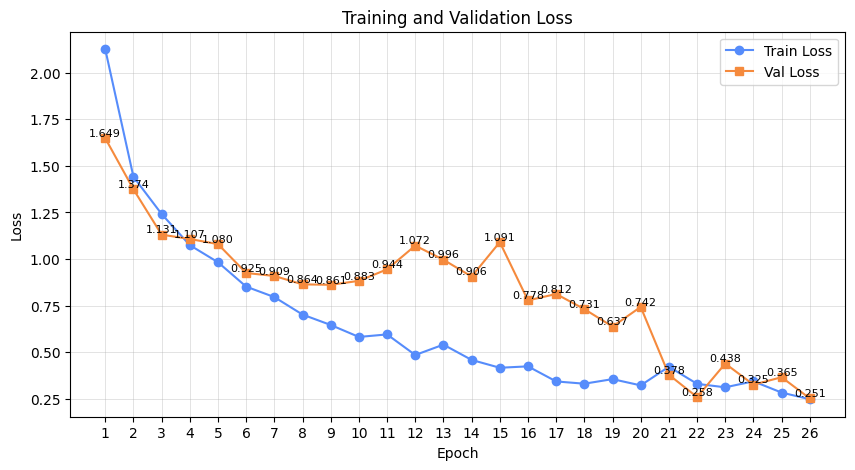

In [2]:

# =========================================
# 3. 绘制 Loss 曲线
# =========================================
plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
for x, y in zip(epochs, val_loss):
    plt.text(x, y+0.01, f"{y:.3f}", fontsize=8, ha='center')
plt.show()

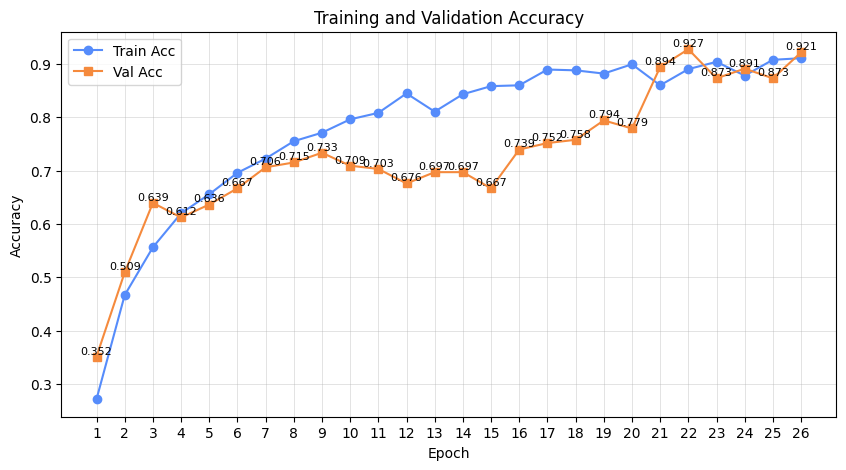

In [3]:

# =========================================
# 4. 绘制 Accuracy 曲线
# =========================================
plt.figure(figsize=(10,5))
plt.plot(epochs, train_acc, label='Train Acc', marker='o')
plt.plot(epochs, val_acc, label='Val Acc', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
for x, y in zip(epochs, val_acc):
    plt.text(x, y+0.005, f"{y:.3f}", fontsize=8, ha='center')
plt.show()

In [5]:
from torchinfo import summary

# 实例化你的模型
model = CatCNN(num_classes=7)

# 传入模型和输入的特征尺寸 (batch_size, channels, height, width)
# 这里我们用你测试代码中的 batch_size=4
model_profile = summary(model, input_size=(4, 3, 224, 224),
                        col_names=["input_size", "output_size", "num_params", "kernel_size"],
                        col_width=20,
                        row_settings=["var_names"])
model_profile

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Kernel Shape
CatCNN (CatCNN)                          [4, 3, 224, 224]     [4, 7]               --                   --
├─Sequential (features)                  [4, 3, 224, 224]     [4, 256, 14, 14]     --                   --
│    └─Conv2d (0)                        [4, 3, 224, 224]     [4, 32, 224, 224]    896                  [3, 3]
│    └─BatchNorm2d (1)                   [4, 32, 224, 224]    [4, 32, 224, 224]    64                   --
│    └─ReLU (2)                          [4, 32, 224, 224]    [4, 32, 224, 224]    --                   --
│    └─Conv2d (3)                        [4, 32, 224, 224]    [4, 32, 224, 224]    9,248                [3, 3]
│    └─BatchNorm2d (4)                   [4, 32, 224, 224]    [4, 32, 224, 224]    64                   --
│    └─ReLU (5)                          [4, 32, 224, 224]    [4, 32, 224, 224]    --                   --
│    └─MaxPool2d (6

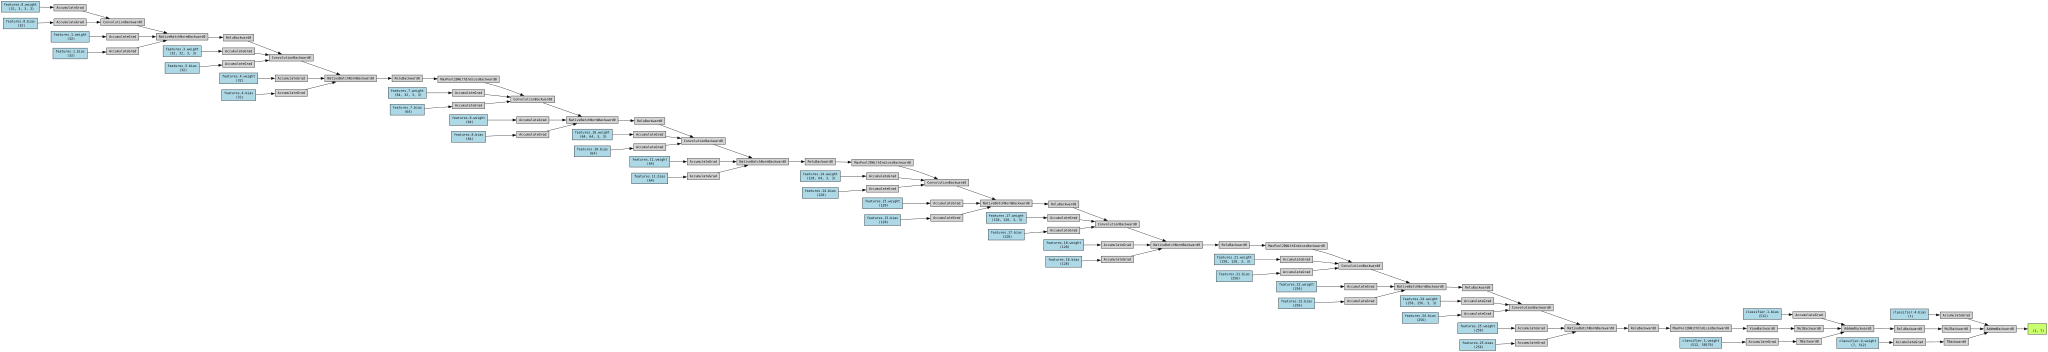

In [6]:
import torch
from torchviz import make_dot

# ==============================
# 1. 准备数据和模型 (使用上文定义的 CatCNN)
# ==============================
model = CatCNN(num_classes=7)
x = torch.randn(1, 3, 224, 224) # 导出时用单张图片即可
y = model(x)

# ==============================
# 2. 生成计算图并修改为横向
# ==============================
# 忽略一些参数让图不要太大
dot = make_dot(y, params=dict(list(model.named_parameters())))

# 核心：修改 Graphviz 属性为横向 (Left to Right)
# 这是把默认的 'TB' (Top to Bottom) 改为 'LR'
dot.attr(rankdir='LR')

# 优化显示效果：使节点更紧凑，使用圆角
dot.attr('node', shape='box', style='filled,rounded', color='lightblue2', fontname='Helvetica')

# 保存并显示
# dot.render("catcnn_compute_graph_horizontal", format="png")
dot